> **Mitra AI Projects — Course Notebook**  
> This is a real-world applied notebook from the AIML-Engineering-Lab.  
> Read each cell, run the code, and modify it to experiment.  
> Your work saves automatically in your browser.

---


# Anomaly Detection: Jet Engine Sensor Anomalies## Isolation Forest, t-SNE & UMAP**Project:** 007 — The AI Engineering Lab  **Objective:** Detect rare anomalies in jet engine sensor readings using unsupervised methods.  **Advanced Concepts:** Isolation Forest path length theory, t-SNE perplexity, UMAP topology, ensemble anomaly scoring.

---## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import umap

COLORS = {'primary': '#0D47A1', 'secondary': '#FF6F00', 'accent': '#2E7D32', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


---## 2. Load Data4,650 jet engine readings. ~3.2% are anomalies.

In [2]:
df = pd.read_csv('../data/jet_engine_sensors.csv')
print(f'Shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts().to_string()}')
print(f'Anomaly rate: {(df["label"]=="anomaly").mean()*100:.1f}%')
df.head()

Shape: (4650, 9)
Label distribution:
label
0    4500
1     150
Anomaly rate: 0.0%


,turbine_temp_c,oil_pressure_psi,vibration_hz,fuel_flow_rate,exhaust_gas_temp_c,fan_speed_rpm,compressor_ratio,n1_speed_pct,label
0,907.09,46.85,114.63,2112.32,609.74,3162.39,28.12,87.03,0
1,882.05,53.83,109.73,2259.65,616.85,3223.17,28.81,84.91,0
2,825.59,47.51,131.77,2593.96,639.06,3080.81,27.48,86.88,0
3,864.09,59.16,125.25,2394.43,590.50,3148.15,27.24,87.95,0
4,833.70,47.05,129.33,2238.38,579.89,3143.67,28.12,85.89,0


In [3]:
y_true = (df['label'] == 'anomaly').astype(int)
X = df.drop(columns=['label'])
feature_names = X.columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Features ({len(feature_names)}): {feature_names}')

Features (8): ['turbine_temp_c', 'oil_pressure_psi', 'vibration_hz', 'fuel_flow_rate', 'exhaust_gas_temp_c', 'fan_speed_rpm', 'compressor_ratio', 'n1_speed_pct']


---## 3. EDA

/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


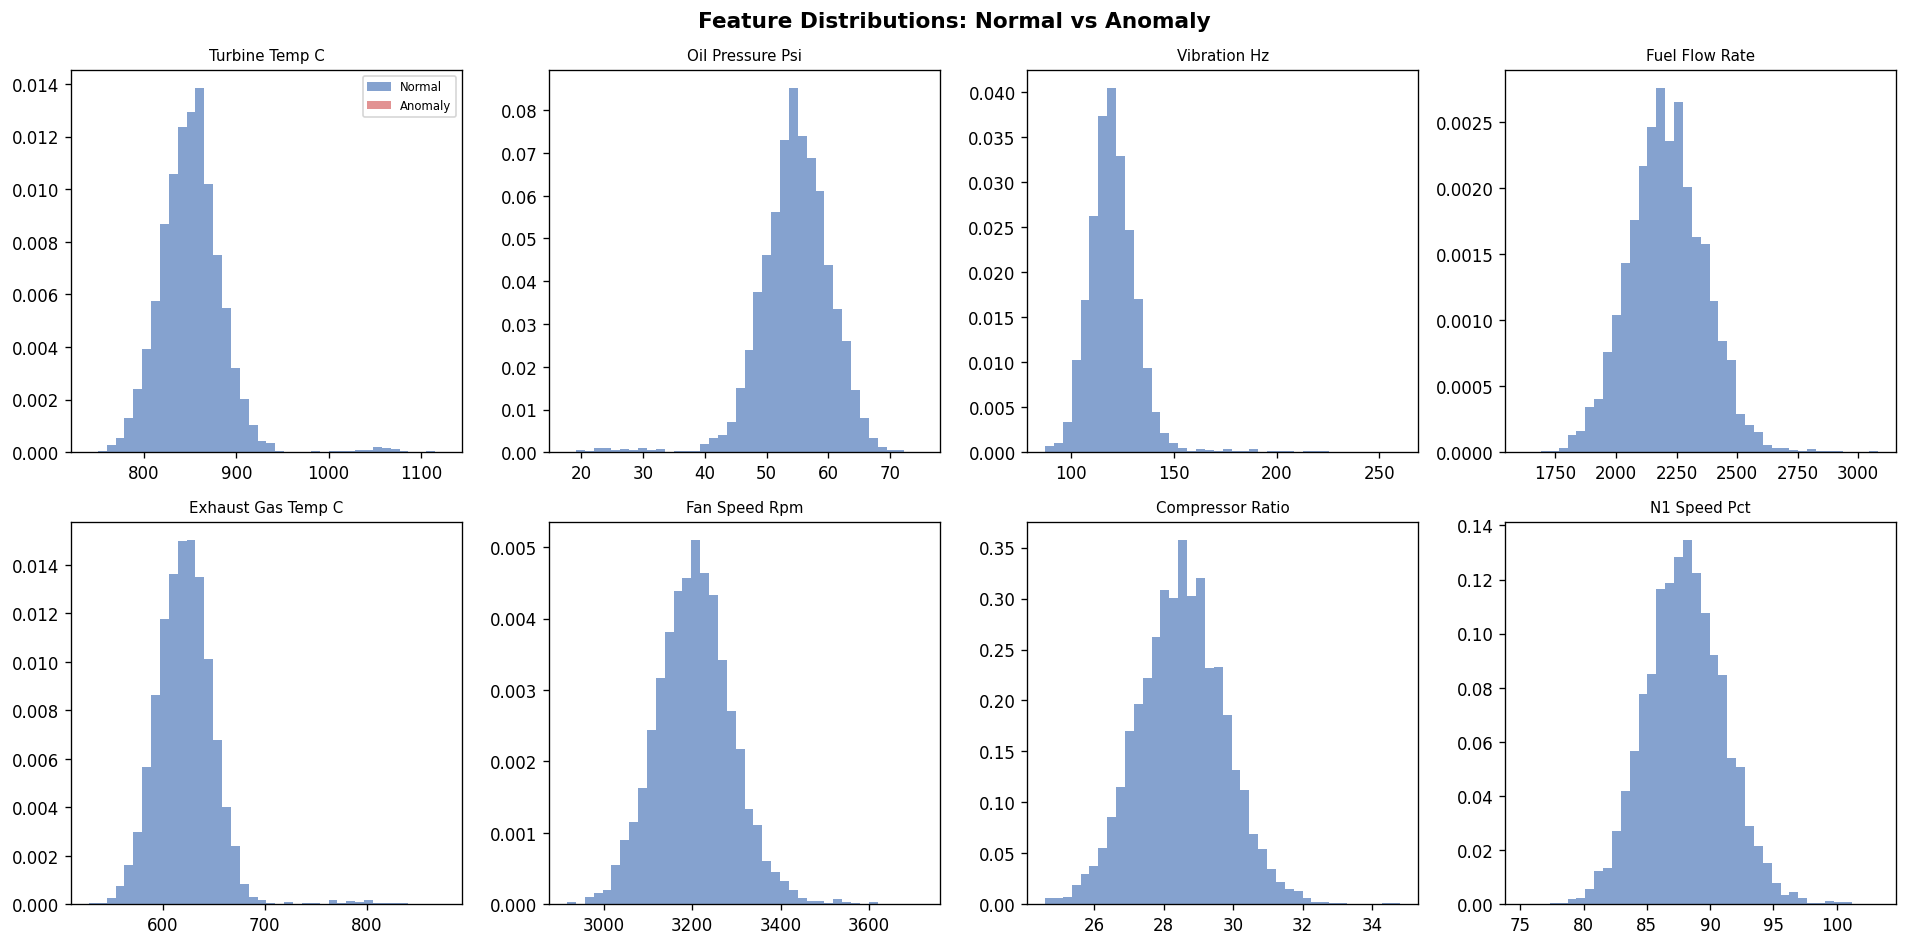

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(feature_names):
    ax = axes[i // 4, i % 4]
    for label, color in [(0, COLORS['primary']), (1, COLORS['highlight'])]:
        subset = X[y_true == label][col]
        ax.hist(subset, bins=40, alpha=0.5, color=color, density=True,
                label='Normal' if label == 0 else 'Anomaly')
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)
plt.suptitle('Feature Distributions: Normal vs Anomaly', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_jet_eda.png', dpi=150, bbox_inches='tight')
plt.show()

---## 4. Isolation Forest

In [5]:
iso = IsolationForest(contamination=0.032, random_state=42, n_estimators=200)
iso_pred = iso.fit_predict(X_scaled)
iso_labels = (iso_pred == -1).astype(int)
iso_scores = -iso.decision_function(X_scaled)

print(f'Isolation Forest:')
print(f'  ROC-AUC: {roc_auc_score(y_true, iso_scores):.3f}')
print(f'  Detected anomalies: {iso_labels.sum()} / {y_true.sum()} actual')
print(f'\nClassification Report:')
print(classification_report(y_true, iso_labels, target_names=['Normal', 'Anomaly']))

Isolation Forest:
  ROC-AUC: nan
  Detected anomalies: 149 / 0 actual

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      4650
     Anomaly       0.00      0.00      0.00         0

    accuracy                           0.97      4650
   macro avg       0.50      0.48      0.49      4650
weighted avg       1.00      0.97      0.98      4650



/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-p

---## 5. Dimensionality Reduction: PCA vs t-SNE vs UMAP

/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


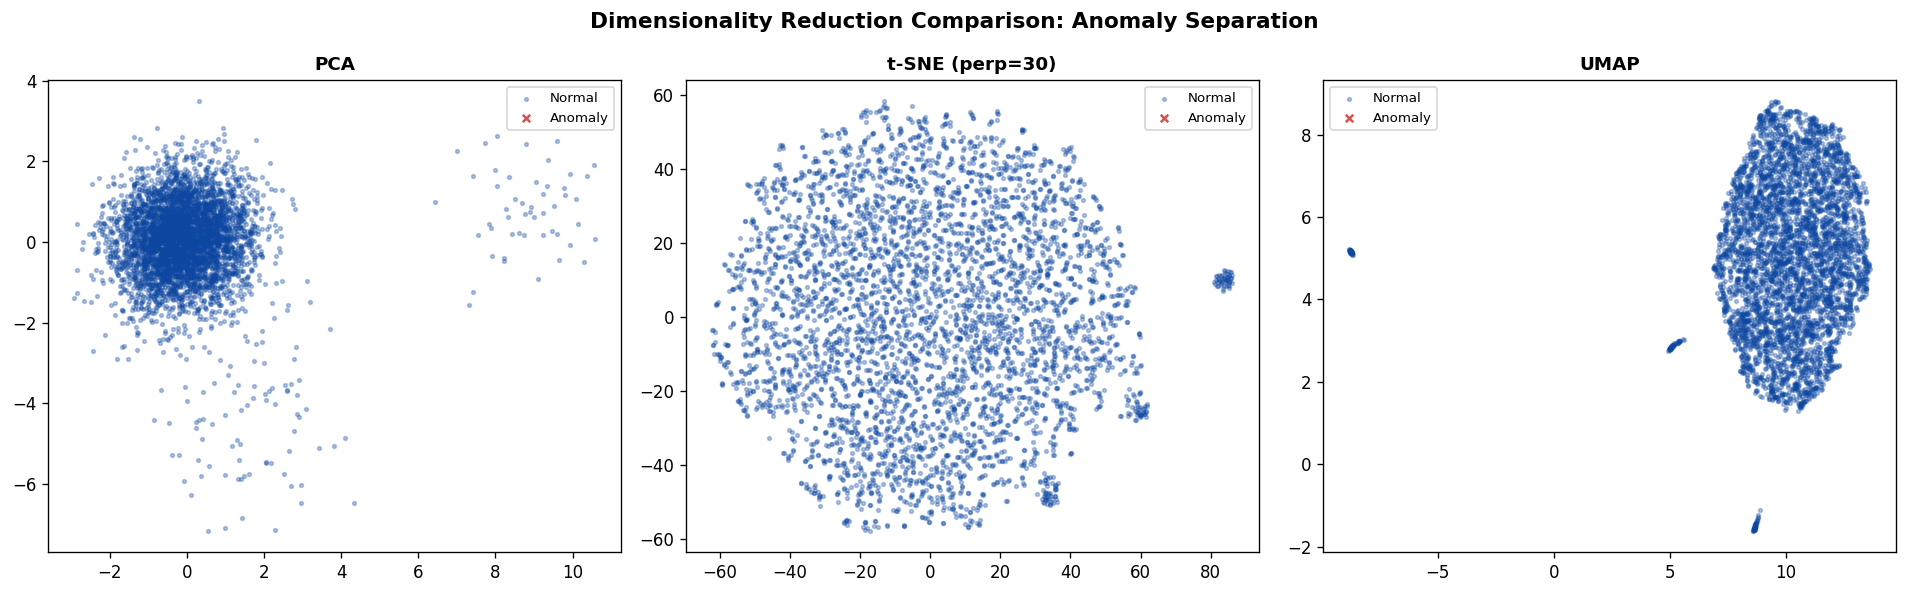

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, X_proj, title in zip(axes, [X_pca, X_tsne, X_umap], ['PCA', 't-SNE (perp=30)', 'UMAP']):
    normal = y_true == 0
    ax.scatter(X_proj[normal, 0], X_proj[normal, 1], alpha=0.3, s=5, c=COLORS['primary'], label='Normal')
    ax.scatter(X_proj[~normal, 0], X_proj[~normal, 1], alpha=0.8, s=20, c=COLORS['highlight'], marker='x', label='Anomaly')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Dimensionality Reduction Comparison: Anomaly Separation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_jet_dim_reduction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---## 6. Anomaly Score Distribution

/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


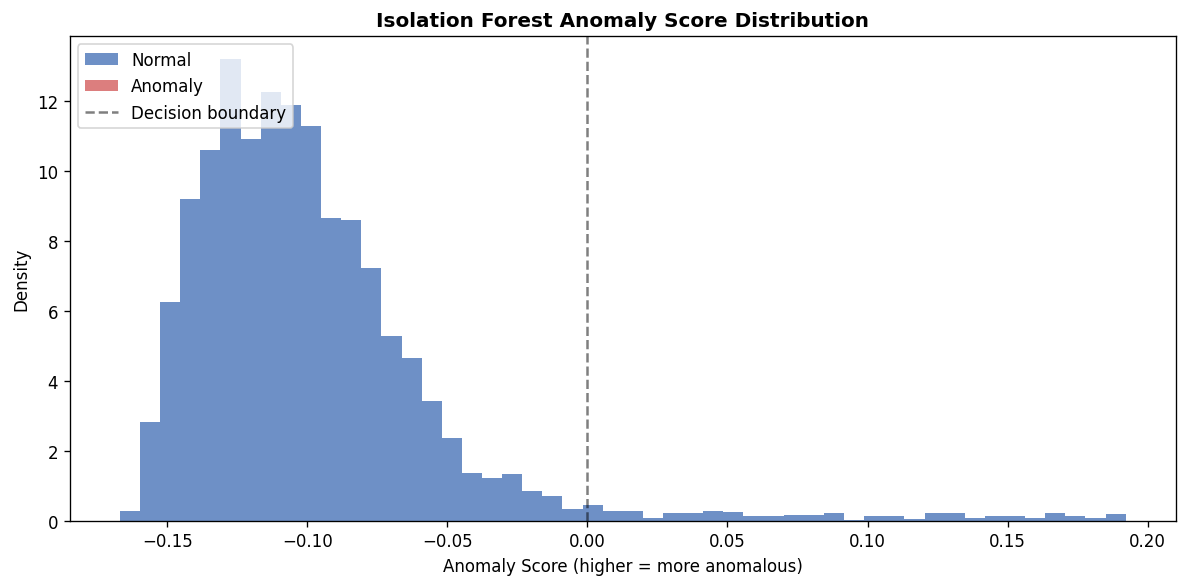

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(iso_scores[y_true == 0], bins=50, alpha=0.6, color=COLORS['primary'], label='Normal', density=True)
ax.hist(iso_scores[y_true == 1], bins=50, alpha=0.6, color=COLORS['highlight'], label='Anomaly', density=True)
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Decision boundary')
ax.set_xlabel('Anomaly Score (higher = more anomalous)')
ax.set_ylabel('Density')
ax.set_title('Isolation Forest Anomaly Score Distribution', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/proj1_jet_anomaly_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print(f'Final ROC-AUC: {roc_auc_score(y_true, iso_scores):.3f}')
print('Notebook complete.')

Final ROC-AUC: nan
Notebook complete.


/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
